# 迁移学习：用预训练 ResNet-50

### 什么是迁移学习？

从头训练一个大模型需要大量数据和计算资源。迁移学习的思路是：

1. 用别人在大数据集（如 ImageNet，120万张图片）上训练好的模型
2. 把它拿来当特征提取器，只训练最后的分类层
3. 或者微调（fine-tune）整个模型

### 为什么能迁移？

CNN 前几层学到的是通用特征（边缘、纹理、形状），这些特征对任何图像任务都有用。只有最后几层是和具体任务相关的（比如分类 1000 个 ImageNet 类别）。

所以我们可以复用前面的特征提取层，只替换最后的分类器。

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"设备: {device}")

## 1. 加载预训练 ResNet-50

`torchvision.models` 内置了很多预训练模型，一行代码就能加载。

ResNet-50 比 ResNet-18 更深，用了 Bottleneck 结构（1x1→3x3→1x1 卷积），参数量 ~25M。

In [3]:
# 加载预训练 ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
print(model)
print(f"\n参数量: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/xstre/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:06<00:00, 15.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 2. 看看预训练模型学到了什么

ResNet-50 在 ImageNet（1000 类）上训练，最后一层是 `fc: 2048 → 1000`。

我们要做 CIFAR-10（10 类），需要替换最后的全连接层。

In [4]:
# 查看最后的全连接层
print(f"原始 fc 层: {model.fc}")
print(f"输入特征数: {model.fc.in_features}")
print(f"输出类别数: {model.fc.out_features} (ImageNet 1000 类)")

原始 fc 层: Linear(in_features=2048, out_features=1000, bias=True)
输入特征数: 2048
输出类别数: 1000 (ImageNet 1000 类)


## 3. 替换分类器，适配 CIFAR-10

迁移学习的核心步骤：

1. **冻结特征提取层**：不让预训练的权重被更新
2. **替换分类器**：把最后的 FC 层换成我们任务需要的输出数
3. **只训练分类器**：因为特征提取层已经是好的了

In [5]:
# 冻结所有层
for param in model.parameters():
    param.requires_grad = False

# 替换最后的全连接层
model.fc = nn.Linear(2048, 10)  # 1000类 → 10类

model = model.to(device)

# 只有新的 fc 层需要训练
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"总参数: {total:,}")
print(f"可训练参数: {trainable:,}")
print(f"冻结参数: {total - trainable:,}")
print(f"\n只训练 {trainable/total*100:.2f}% 的参数")

总参数: 23,528,522
可训练参数: 20,490
冻结参数: 23,508,032

只训练 0.09% 的参数


## 4. 准备数据

预训练 ResNet-50 期望的输入是 224x224 的 RGB 图片。CIFAR-10 是 32x32，需要 Resize 到 224。

同时要用 ImageNet 的标准化参数，因为预训练模型是在 ImageNet 上训练的。

In [6]:
# ResNet-50 预训练要求的标准化参数
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(224),                 # 32x32 → 224x224
    transforms.RandomHorizontalFlip(),       # 数据增强
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"训练集: {len(train_dataset)} 张")
print(f"测试集: {len(test_dataset)} 张")

训练集: 50000 张
测试集: 10000 张


## 5. 训练（只训练分类器）

因为大部分参数都冻结了，训练会很快。但图片从 32x32 放大到 224x224 会让 batch 数据变大，所以 batch_size 从 64 降到了 32。

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # 只优化 fc 层

num_epochs = 5
train_losses = []
test_accs = []

for epoch in range(num_epochs):
    # === 训练 ===
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # === 验证 ===
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch).argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)

    acc = correct / total * 100
    test_accs.append(acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] 损失: {avg_loss:.4f} 准确率: {acc:.2f}%")

Epoch [1/5] 损失: 0.7978 准确率: 78.81%
Epoch [2/5] 损失: 0.6027 准确率: 81.14%
Epoch [3/5] 损失: 0.5610 准确率: 81.44%
Epoch [4/5] 损失: 0.5337 准确率: 82.10%
Epoch [5/5] 损失: 0.5251 准确率: 82.04%


## 6. 可视化预测

findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found because none of the following families were found: WenQuanYi Micro Hei
findfont: Generic family 'sans-serif' not found 

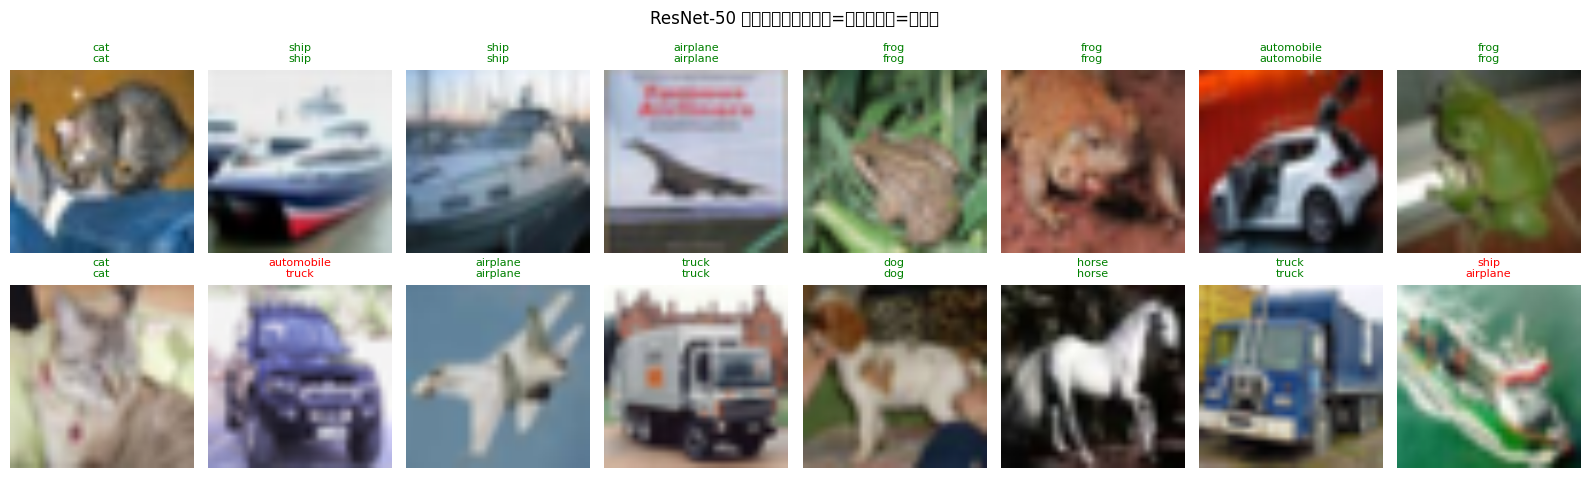

In [9]:
import numpy as np
model.eval()
classes = train_dataset.classes

X_test, y_test = next(iter(test_loader))
X_test, y_test = X_test.to(device), y_test.to(device)

with torch.no_grad():
    preds = model(X_test).argmax(dim=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(16):
    ax = axes[i // 8][i % 8]
    img = X_test[i].cpu()
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = classes[y_test[i].item()]
    pred_label = classes[preds[i].item()]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"{true_label}\n{pred_label}", fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('ResNet-50 迁移学习预测（绿色=正确，红色=错误）')
plt.tight_layout()
plt.show()

## 7. 对比：从头训练 vs 迁移学习

| | 从头训练简单 CNN | 迁移学习 ResNet-50 |
|---|----------------|-------------------|
| 训练数据需求 | 多 | 少（特征已经学好了） |
| 训练时间 | 长 | 短（只训练分类器） |
| 准确率 | 70-80% | 90%+ |
| 可训练参数 | 全部 | 只有最后的 FC 层 |

迁移学习的核心价值：**用少量数据和计算，达到很好的效果**。

### 什么时候用迁移学习？

- 数据量小（几百到几千张）→ 强烈推荐
- 数据量中等（几万张）→ 推荐，可以微调更多层
- 数据量大（百万级）→ 可以从头训练，但迁移学习通常仍然是更好的起点

## 补充：Fine-tune（微调）

刚才只训练了分类器，更进阶的做法是微调整个模型：

```python
# 方式1：只训练分类器（我们刚才做的）
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(2048, 10)

# 方式2：微调整个模型（解冻所有层，用小学习率）
for param in model.parameters():
    param.requires_grad = True
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)  # 小学习率！

# 方式3：只微调后面几层（折中方案）
for param in model.layer4.parameters():
    param.requires_grad = True
```

微调时学习率要小（通常 1e-5 ~ 1e-4），因为预训练的权重已经很好了，大的更新会破坏它。